## 15. DBFNet Regularizado

In [1]:
import torch
import numpy as np

TARGET_SR = 16_000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
N_FOLDS = 5
TEST_SIZE = 0

%load_ext autoreload
%autoreload 2

print(f"Device: {DEVICE}")
print(f"Test size: {TEST_SIZE:.0%}")

Device: mps
Test size: 0%


### Preprocesamiento

In [2]:
from src.preprocessing import load_waveforms, preprocess_waveform, load_metadata

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

/Users/napster/Documents/upm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Embeddings temporales

In [3]:
from src.embeddings import extract_multilayer_embeddings

w2v_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/wav2vec2-base", [0], DEVICE
)
emb_w2v_L0 = w2v_layers[0]

2026-04-05 21:06:30,025 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-04-05 21:06:30,636 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-05 21:06:30,744 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-05 21:06:30,899 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-05 21:06:30,900 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-05 21:06:31,080 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-05 21:06:31,232 [INFO

  25/100
  50/100
  75/100
  100/100


### Features expectrales de Resnet

In [4]:
from src.spectral import extract_spectral_features

MEL_CONFIG = {
    "sample_rate": TARGET_SR,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 128,
}

spectral_features = extract_spectral_features(
    waveforms_processed, device=DEVICE, **MEL_CONFIG
)

2026-04-05 21:06:36,715 [INFO] src.config: Generando mel-espectrogramas...
2026-04-05 21:06:36,761 [INFO] src.config:   100 espectrogramas generados
2026-04-05 21:06:36,761 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-04-05 21:06:36,761 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...
2026-04-05 21:06:37,029 [INFO] src.config:   25/100
2026-04-05 21:06:37,096 [INFO] src.config:   50/100
2026-04-05 21:06:37,163 [INFO] src.config:   75/100
2026-04-05 21:06:37,229 [INFO] src.config:   100/100
2026-04-05 21:06:37,230 [INFO] src.config:   Features espectrales: (100, 512)


### Normalización y Holdout Split

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_t = StandardScaler()
scaler_s = StandardScaler()
emb_t_all = scaler_t.fit_transform(emb_w2v_L0)
emb_s_all = scaler_s.fit_transform(spectral_features)
labels_all = df_metadata["label"].to_numpy()

if TEST_SIZE > 0:
    train_val_idx, test_idx = train_test_split(
        np.arange(len(labels_all)),
        test_size=TEST_SIZE,
        stratify=labels_all,
        random_state=RANDOM_STATE,
    )
    # Test (intocable)
    emb_t_test  = emb_t_all[test_idx]
    emb_s_test  = emb_s_all[test_idx]
    labels_test = labels_all[test_idx]

    # CV
    emb_t_cv  = emb_t_all[train_val_idx]
    emb_s_cv  = emb_s_all[train_val_idx]
    labels_cv = labels_all[train_val_idx]
else:
    emb_t_cv  = emb_t_all
    emb_s_cv  = emb_s_all
    labels_cv = labels_all

print(f"Total: {len(labels_all)} sujetos")
print(f"  CV:   {len(labels_cv)} (PD={labels_cv.sum():.0f}, HC={len(labels_cv) - labels_cv.sum():.0f})")
if TEST_SIZE > 0:
    print(f"  Test: {len(labels_test)} (PD={labels_test.sum():.0f}, HC={len(labels_test) - labels_test.sum():.0f})")

Total: 100 sujetos
  CV:   100 (PD=50, HC=50)


## Entrenamiento regularizado

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader
from src.models import DualBranchFusionNet
from src.datasets import DualBranchDataset

def train_fold_regularized(train_ds, val_ds, device,
                           lr=1e-3, weight_decay=1e-4, label_smoothing=0.0,
                           dropout=0.3, dim_proj=128, dim_hidden=64,
                           epochs=120, patience=20, batch_size=8,
                           scheduler_factor=0.5, scheduler_patience=7):
    """
    Entrena un fold de DBFNet con regularizacion completa:
    AdamW + label smoothing + ReduceLROnPlateau + early stopping.

    Returns: y_true, y_prob, alphas, history
    """
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=len(val_ds))

    model = DualBranchFusionNet(
        dim_proj=dim_proj, dim_hidden=dim_hidden, dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=scheduler_factor,
        patience=scheduler_patience
    )

    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for z_t, z_s, y in train_loader:
            z_t, z_s, y = z_t.to(device), z_s.to(device), y.to(device)

            if label_smoothing > 0:
                y = y * (1 - label_smoothing) + label_smoothing / 2

            logits, _ = model(z_t, z_s)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            z_t_v, z_s_v, y_v = next(iter(val_loader))
            z_t_v, z_s_v, y_v = z_t_v.to(device), z_s_v.to(device), y_v.to(device)
            logits_v, alphas_v = model(z_t_v, z_s_v)
            val_loss = criterion(logits_v, y_v).item()

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = model.state_dict().copy()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        z_t_v, z_s_v, y_v = next(iter(val_loader))
        z_t_v, z_s_v, y_v = z_t_v.to(device), z_s_v.to(device), y_v.to(device)
        logits_v, alphas_v = model(z_t_v, z_s_v)
        y_prob = torch.sigmoid(logits_v).cpu().numpy()
        y_true = y_v.cpu().numpy()
        alphas = alphas_v.cpu().numpy()

    return y_true, y_prob, alphas, history

## Busqueda de hiperparametros con Optuna

In [7]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    lr             = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay   = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout        = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025)
    batch_size     = trial.suggest_categorical("batch_size", [8, 16, 32])
    dim_proj       = trial.suggest_categorical("dim_proj", [64, 128, 256])
    dim_hidden     = trial.suggest_categorical("dim_hidden", [32, 64, 128])

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []

    for train_idx, val_idx in skf.split(emb_t_cv, labels_cv):
        train_ds = DualBranchDataset(emb_t_cv, emb_s_cv, labels_cv, train_idx)
        val_ds   = DualBranchDataset(emb_t_cv, emb_s_cv, labels_cv, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(
            train_ds, val_ds, DEVICE,
            lr=lr, weight_decay=weight_decay, label_smoothing=label_smoothing,
            dropout=dropout, dim_proj=dim_proj, dim_hidden=dim_hidden,
            batch_size=batch_size, epochs=120, patience=20,
        )
        fold_aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)

    trial.set_user_attr("auc_mean", mean_auc)
    trial.set_user_attr("auc_std", std_auc)

    return mean_auc - 0.5 * std_auc


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="dbfnet_regularization"
)
study.optimize(objective, n_trials=75, show_progress_bar=True)

Best trial: 42. Best value: 0.866988: 100%|██████████| 75/75 [05:08<00:00,  4.11s/it]


### Resultados

In [12]:
best = study.best_trial
print(f"Mejor trial #{best.number}")
print(f"  Score (AUC - 0.5*std): {best.value:.4f}")
print(f"  AUC: {best.user_attrs['auc_mean']:.3f} +/- {best.user_attrs['auc_std']:.3f}")
print(f"  Parametros:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Mejor trial #42
  Score (AUC - 0.5*std): 0.8670
  AUC: 0.910 +/- 0.086
  Parametros:
    lr: 0.00012786728092781501
    weight_decay: 0.0015780942840282076
    dropout: 0.45000000000000007
    label_smoothing: 0.05
    batch_size: 32
    dim_proj: 128
    dim_hidden: 128


## Evaluacion con mejores hiperparametros (CV sobre el set de entrenamiento)

In [13]:
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

bp = study.best_params
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec, fold_alphas = [], [], [], [], []
all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_cv, labels_cv)):
    train_ds = DualBranchDataset(emb_t_cv, emb_s_cv, labels_cv, train_idx)
    val_ds   = DualBranchDataset(emb_t_cv, emb_s_cv, labels_cv, val_idx)

    y_true, y_prob, alphas, history = train_fold_regularized(
        train_ds, val_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        label_smoothing=bp["label_smoothing"], dropout=bp["dropout"],
        dim_proj=bp["dim_proj"], dim_hidden=bp["dim_hidden"],
        batch_size=bp["batch_size"], epochs=120, patience=20,
    )

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thr).astype(int)

    auc  = roc_auc_score(y_true, y_prob)
    acc  = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    spec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)

    fold_aucs.append(auc)
    fold_accs.append(acc)
    fold_sens.append(sens)
    fold_spec.append(spec)
    fold_alphas.append(alphas.mean())
    all_histories.append(history)

    print(f"  Fold {fold_idx+1}: AUC={auc:.3f}  Acc={acc:.3f}  Sens={sens:.3f}  Spec={spec:.3f}")

print(f"\nDBFNet Regularizado (CV sobre {len(labels_cv)} sujetos)")
print("=" * 55)
print(f"  AUC:  {np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs):.3f}")
print(f"  Acc:  {np.mean(fold_accs):.3f} +/- {np.std(fold_accs):.3f}")
print(f"  Sens: {np.mean(fold_sens):.3f} +/- {np.std(fold_sens):.3f}")
print(f"  Spec: {np.mean(fold_spec):.3f} +/- {np.std(fold_spec):.3f}")
print(f"  alpha: {np.mean(fold_alphas):.3f}")

cv_pearson = (np.std(fold_aucs) / np.mean(fold_aucs)) * 100
print(f"  CV Pearson (AUC): {cv_pearson:.1f}%")

  Fold 1: AUC=0.940  Acc=0.900  Sens=0.900  Spec=0.900
  Fold 2: AUC=0.810  Acc=0.850  Sens=0.700  Spec=1.000
  Fold 3: AUC=0.790  Acc=0.800  Sens=0.700  Spec=0.900
  Fold 4: AUC=0.980  Acc=0.950  Sens=1.000  Spec=0.900
  Fold 5: AUC=0.990  Acc=0.950  Sens=0.900  Spec=1.000

DBFNet Regularizado (CV sobre 100 sujetos)
  AUC:  0.902 +/- 0.085
  Acc:  0.890 +/- 0.058
  Sens: 0.840 +/- 0.120
  Spec: 0.940 +/- 0.049
  alpha: 0.740
  CV Pearson (AUC): 9.4%


### Curvas de perdida por fold

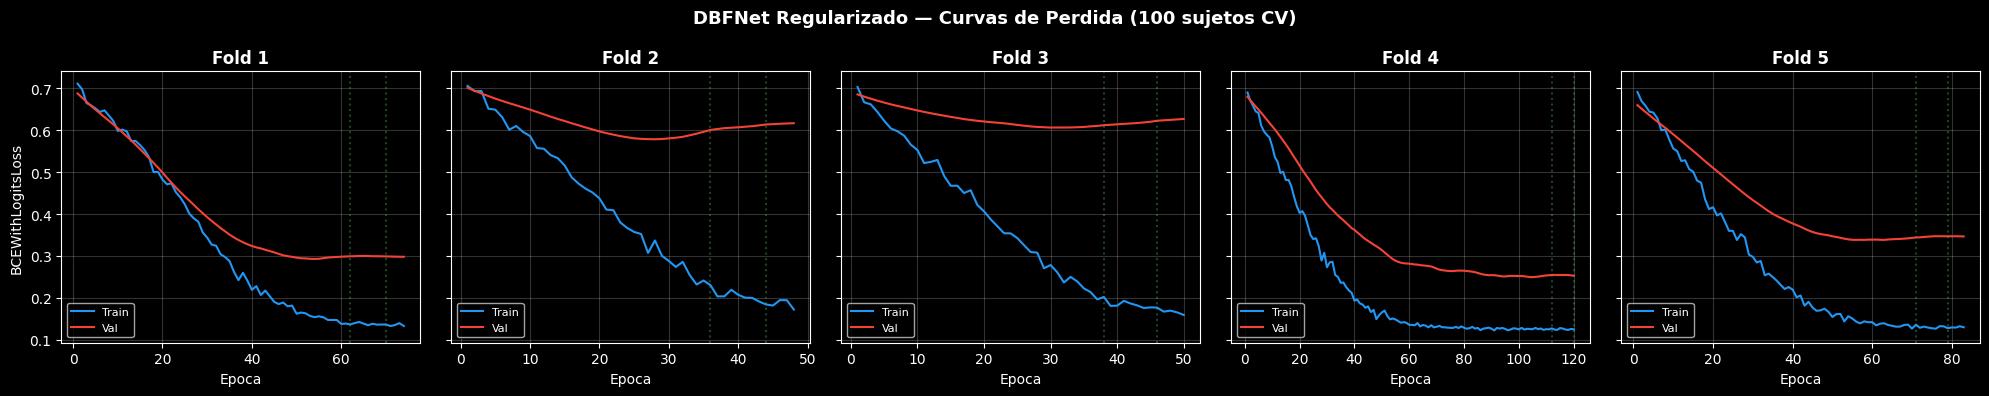

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, N_FOLDS, figsize=(20, 4), sharey=True)

for i, (ax, hist) in enumerate(zip(axes, all_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", linewidth=1.5, color="#2196F3")
    ax.plot(epochs, hist["val_loss"],   label="Val",   linewidth=1.5, color="#F44336")

    for j, lr_val in enumerate(hist["lr"]):
        if j > 0 and lr_val < hist["lr"][j-1]:
            ax.axvline(j+1, color="#4CAF50", linestyle=":", alpha=0.4)

    ax.set_title(f"Fold {i+1}", fontweight="bold")
    ax.set_xlabel("Epoca")
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.set_ylabel("BCEWithLogitsLoss")
    ax.legend(fontsize=8)

plt.suptitle(
    f"DBFNet Regularizado — Curvas de Perdida ({len(labels_cv)} sujetos CV)",
    fontweight="bold", fontsize=13
)
plt.tight_layout()
plt.show()

### Evaluacion final en test holdout

In [16]:
if TEST_SIZE > 0:
    # --- Evaluacion en el holdout (datos nunca vistos) ---
    bp = study.best_params

    train_ds_final = DualBranchDataset(
        emb_t_cv, emb_s_cv, labels_cv, np.arange(len(labels_cv))
    )
    test_ds_final = DualBranchDataset(
        emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test))
    )

    N_SEEDS = 5
    test_probs = []

    for seed in range(N_SEEDS):
        torch.manual_seed(seed)
        np.random.seed(seed)

        y_true, y_prob, alphas, _ = train_fold_regularized(
            train_ds_final, test_ds_final, DEVICE,
            lr=bp["lr"], weight_decay=bp["weight_decay"],
            label_smoothing=bp["label_smoothing"], dropout=bp["dropout"],
            dim_proj=bp["dim_proj"], dim_hidden=bp["dim_hidden"],
            batch_size=bp["batch_size"], epochs=120, patience=20,
        )
        test_probs.append(y_prob)

    y_prob_ensemble = np.mean(test_probs, axis=0)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob_ensemble)
    best_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred_final = (y_prob_ensemble >= best_thr).astype(int)

    print(f"RESULTADO EN TEST HOLDOUT ({TEST_SIZE:.0%} = {len(labels_test)} sujetos)")
    print("=" * 55)
    print(f"  AUC:           {roc_auc_score(y_true, y_prob_ensemble):.3f}")
    print(f"  Accuracy:      {accuracy_score(y_true, y_pred_final):.3f}")
    print(f"  Sensibilidad:  {recall_score(y_true, y_pred_final, pos_label=1):.3f}")
    print(f"  Especificidad: {recall_score(y_true, y_pred_final, pos_label=0):.3f}")
    print(f"  Umbral:        {best_thr:.3f}")
    print(f"  Ensemble:      {N_SEEDS} seeds")

else:
    # --- Sin holdout: mostrar resultados detallados por fold ---
    print(f"TEST_SIZE = 0 — Resultados por fold (100% CV)")
    print("=" * 55)
    for i in range(N_FOLDS):
        print(f"  Fold {i+1}: AUC={fold_aucs[i]:.3f}  Acc={fold_accs[i]:.3f}  "
              f"Sens={fold_sens[i]:.3f}  Spec={fold_spec[i]:.3f}")

    print(f"\nPromedio:")
    print(f"  AUC:  {np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs):.3f}")
    print(f"  Acc:  {np.mean(fold_accs):.3f} +/- {np.std(fold_accs):.3f}")
    print(f"  Sens: {np.mean(fold_sens):.3f} +/- {np.std(fold_sens):.3f}")
    print(f"  Spec: {np.mean(fold_spec):.3f} +/- {np.std(fold_spec):.3f}")
    print(f"  CV Pearson (AUC): {(np.std(fold_aucs) / np.mean(fold_aucs)) * 100:.1f}%")

TEST_SIZE = 0 — Resultados por fold (100% CV)
  Fold 1: AUC=0.940  Acc=0.900  Sens=0.900  Spec=0.900
  Fold 2: AUC=0.810  Acc=0.850  Sens=0.700  Spec=1.000
  Fold 3: AUC=0.790  Acc=0.800  Sens=0.700  Spec=0.900
  Fold 4: AUC=0.980  Acc=0.950  Sens=1.000  Spec=0.900
  Fold 5: AUC=0.990  Acc=0.950  Sens=0.900  Spec=1.000

Promedio:
  AUC:  0.902 +/- 0.085
  Acc:  0.890 +/- 0.058
  Sens: 0.840 +/- 0.120
  Spec: 0.940 +/- 0.049
  CV Pearson (AUC): 9.4%
